## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DATA = "data"
plt.rcParams["figure.figsize"] = (9, 4)
torch.manual_seed(42)
np.random.seed(42)

## 2. Load the dataset

In [2]:
train = datasets.MNIST(DATA, train=True, download=True)
test = datasets.MNIST(DATA, train=False, download=True)

X_train, y_train = train.data.numpy(), train.targets.numpy()
X_test, y_test = test.data.numpy(), test.targets.numpy()
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (60000, 28, 28)  Test: (10000, 28, 28)


## 3. Dataset statistics

In [3]:
summary = pd.DataFrame({
    "split": ["train", "test"],
    "samples": [len(y_train), len(y_test)],
    "classes": [len(np.unique(y_train)), len(np.unique(y_test))],
    "img_shape": [str(X_train.shape[1:]), str(X_test.shape[1:])],
    "pixel_mean": [X_train.mean() / 255, X_test.mean() / 255],
    "pixel_std": [X_train.std() / 255, X_test.std() / 255],
})
summary

,split,samples,classes,img_shape,pixel_mean,pixel_std
0,train,60000,10,"(28, 28)",0.130660,0.308108
1,test,10000,10,"(28, 28)",0.132515,0.310480


## 4. Class distribution

Check whether the digits are balanced across train and test splits.

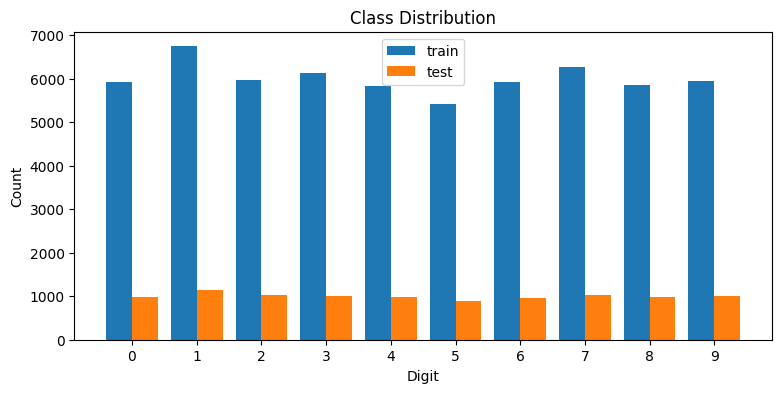

In [4]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

x, w = np.arange(10), 0.4
plt.bar(x - w / 2, train_counts, w, label="train")
plt.bar(x + w / 2, test_counts, w, label="test")
plt.xticks(x)
plt.xlabel("Digit"); plt.ylabel("Count")
plt.title("Class Distribution"); plt.legend(); plt.show()

## 5. Sample images

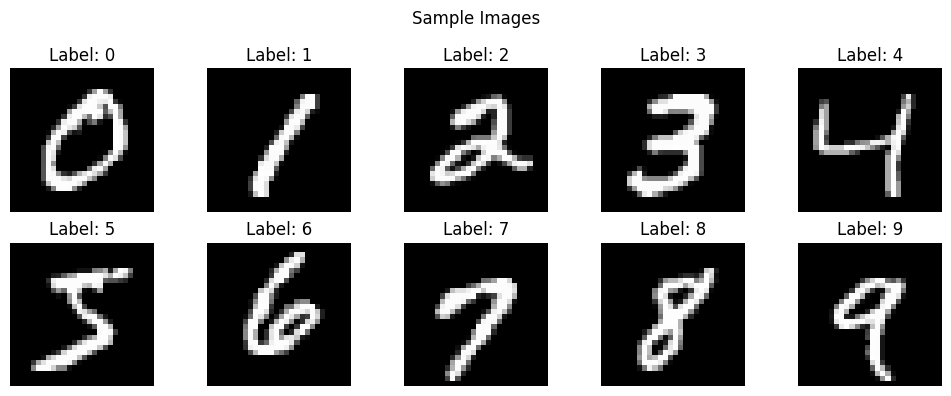

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in zip(range(10), axes.ravel()):
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(f"Label: {digit}"); ax.axis("off")
plt.suptitle("Sample Images"); plt.tight_layout(); plt.show()

## 6. Average image per class

The mean of all images for each digit reveals its characteristic shape and
the variation in handwriting style.

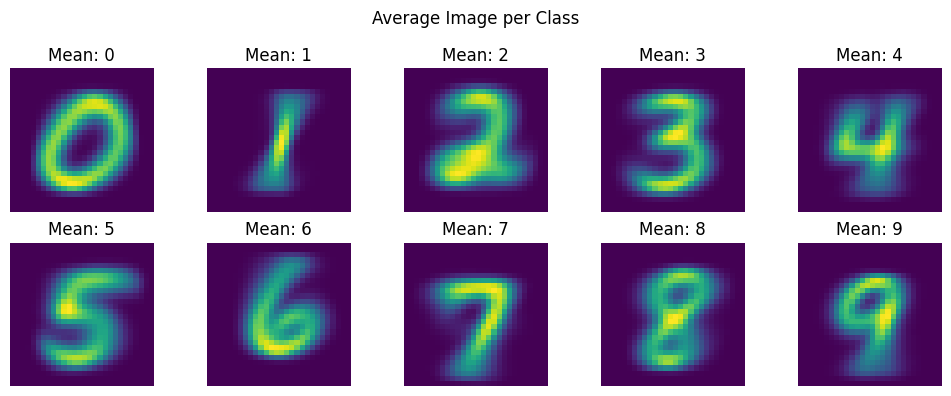

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in zip(range(10), axes.ravel()):
    mean_img = X_train[y_train == digit].mean(axis=0)
    ax.imshow(mean_img, cmap="viridis")
    ax.set_title(f"Mean: {digit}"); ax.axis("off")
plt.suptitle("Average Image per Class"); plt.tight_layout(); plt.show()

## 7. Pixel-intensity statistics

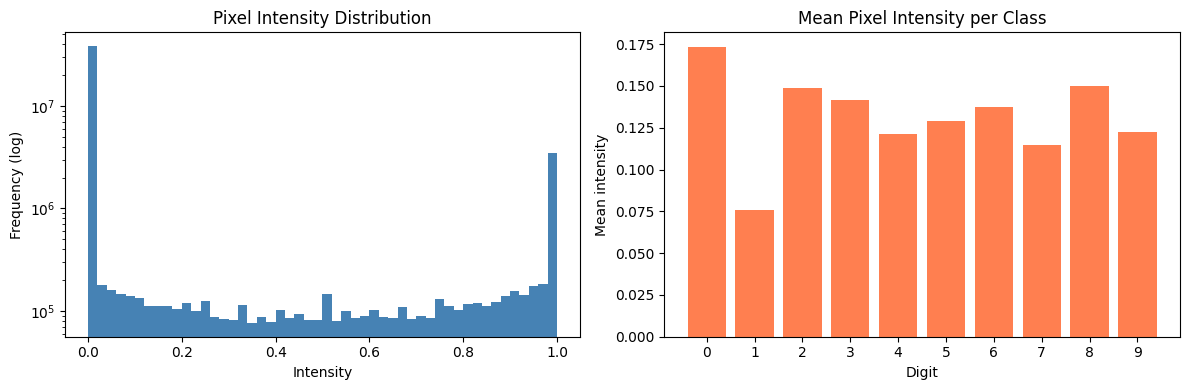

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist((X_train / 255).ravel(), bins=50, color="steelblue")
ax[0].set_yscale("log")
ax[0].set_title("Pixel Intensity Distribution")
ax[0].set_xlabel("Intensity"); ax[0].set_ylabel("Frequency (log)")

mean_per_class = [(X_train[y_train == d] / 255).mean() for d in range(10)]
ax[1].bar(range(10), mean_per_class, color="coral")
ax[1].set_xticks(range(10))
ax[1].set_title("Mean Pixel Intensity per Class")
ax[1].set_xlabel("Digit"); ax[1].set_ylabel("Mean intensity")

plt.tight_layout(); plt.show()

## 8. Model

In [8]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10, in_channels=1):
        super().__init__()

        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(in_channels, 64),   # 28 -> 14
            block(64, 128),           # 14 -> 7
            block(128, 256),          # 7 -> 3
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


_m = LeNet()
print(_m)
print("Trainable parameters:", sum(p.numel() for p in _m.parameters()))


LeNet(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, s

## 9. Training setup

Data augmentation on the train split, Adam + cosine LR schedule, cross-entropy loss.

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS, BATCH, LR = 5, 128, 1e-3
MEAN, STD = 0.1307, 0.3081

train_tf = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

train_ds = datasets.MNIST(DATA, train=True, download=True, transform=train_tf)
test_ds = datasets.MNIST(DATA, train=False, download=True, transform=test_tf)
train_loader = DataLoader(train_ds, BATCH, shuffle=True)
test_loader = DataLoader(test_ds, BATCH)

model = LeNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS)
criterion = nn.CrossEntropyLoss()
print("Training on", device)

Training on cuda


## 10. Training loop

In [10]:
@torch.no_grad()
def evaluate():
    model.eval()
    loss_sum = correct = total = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "test_loss": [], "test_acc": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * y.size(0)
    scheduler.step()
    tr_loss = running / len(train_ds)
    te_loss, te_acc = evaluate()
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
    print(f"Epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}")

Epoch 1/5  train_loss=0.1854  test_loss=0.2358  test_acc=0.9293
Epoch 2/5  train_loss=0.0559  test_loss=0.0339  test_acc=0.9896
Epoch 3/5  train_loss=0.0392  test_loss=0.0156  test_acc=0.9949
Epoch 4/5  train_loss=0.0284  test_loss=0.0176  test_acc=0.9950
Epoch 5/5  train_loss=0.0195  test_loss=0.0105  test_acc=0.9963


## 11. Training curves

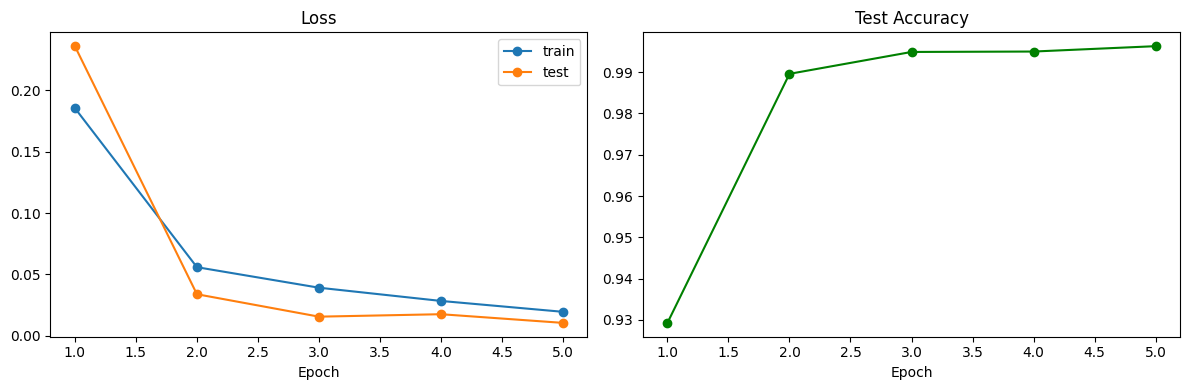

In [11]:
ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, history["train_loss"], "-o", label="train")
ax[0].plot(ep, history["test_loss"], "-o", label="test")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(ep, history["test_acc"], "-o", color="green")
ax[1].set_title("Test Accuracy"); ax[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

## 12. Evaluation

Final test accuracy: 0.9963


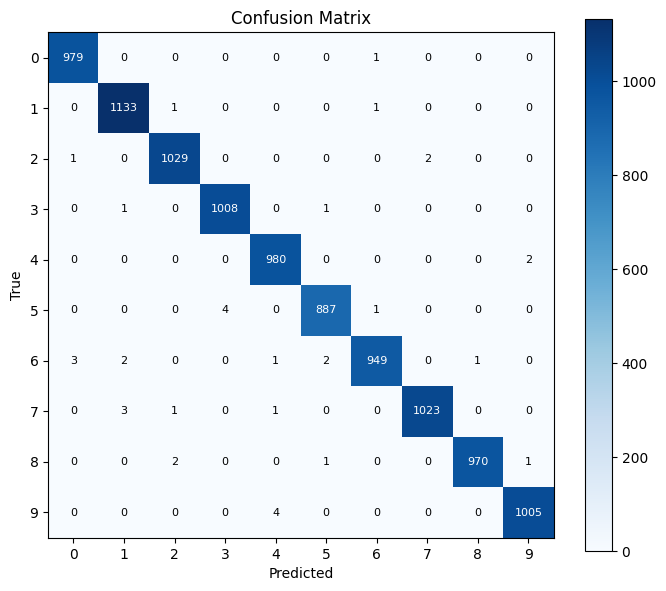

In [12]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in test_loader:
        all_preds.append(model(x.to(device)).argmax(1).cpu())
        all_targets.append(y)
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
print(f"Final test accuracy: {(all_preds == all_targets).mean():.4f}")

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_targets, all_preds):
    cm[t, p] += 1
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
fig.colorbar(im); plt.tight_layout(); plt.show()

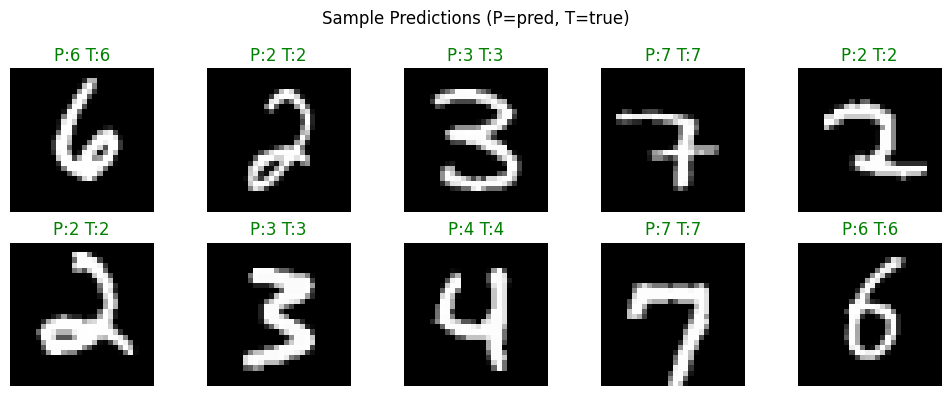

In [13]:
idxs = np.random.choice(len(test_ds), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), idxs):
    ax.imshow(test_ds.data[idx].numpy(), cmap="gray")
    ok = all_preds[idx] == all_targets[idx]
    ax.set_title(f"P:{all_preds[idx]} T:{all_targets[idx]}", color="green" if ok else "red")
    ax.axis("off")
plt.suptitle("Sample Predictions (P=pred, T=true)"); plt.tight_layout(); plt.show()

## 13. Save artifacts for the API

Writes the same `artifacts/` the FastAPI service (`app.py`) loads at startup.

In [14]:
import json
from pathlib import Path

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
torch.save(model.state_dict(), ARTIFACTS / "lenet_mnist.pt")
meta = {
    "architecture": "LeNet", "num_classes": 10, "in_channels": 1,
    "input_size": [28, 28], "normalize": {"mean": [MEAN], "std": [STD]},
    "classes": [str(i) for i in range(10)],
    "best_accuracy": round(float(history["test_acc"][-1]), 4),
    "weights": "lenet_mnist.pt",
}
(ARTIFACTS / "metadata.json").write_text(json.dumps(meta, indent=2))
print("Saved artifacts ->", ARTIFACTS.resolve())

Saved artifacts -> N:\computer-vision\01-image-classification\lenet-mnist\artifacts
